# Sampling and the Central Limit Theorem

Rarely, if ever, are we able to completely survey a population of interest. Similarly, we will often deal with missing data. Whatever it may be, whether estimating asthma rates, fish populations, daily temperatures, material volumes, risk, manufacturing defects or any other measurement of unknown or large scale quantities, we are unlikely to have complete information of the system in question. As a result, we do our best by taking samples and using these to estimate the corresponding measurements for the complete population, from which we took the sample. These estimates of population parameters are known as **point estimates**. Interestingly, point estimates of specific parameters of a population have predictable behaviors, in that the point estimates themselves will form specific probability distributions. For example, we may want to know information about the age of a population. One parameter we might want to estimate is the mean age of the population. Once we take a sample, we can take the mean age of that sample and that would become the point estimate for the mean age of the entire population. If we continue to take more samples from the population, the mean age of each of these samples will begin to form a normal distribution! This intriguing fact lets us apply some logic and calculate confidence intervals surrounding our point estimates so that we not only have a best guess for the parameter, but also can have a range to describe various levels of certainty for our estimates. Ideally, these ranges will be small, indicating that we have a high degree of confidence that the parameter is very close to our estimate.

Let's start by importing a dataset to use for demonstration. In this case, we'll use a datafile concerning individuals who were on board the Titanic. We'll use this as our entire population and start to observe how the point estimates from various samples of this population behave.

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('data/introduction_to_sampling/titanic.csv')
print(len(df))
df.head()

891


,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


If we take a look at the population mean age we have:

In [ ]:
df.Age.mean()

29.69911764705882

Let's see what happens when we take a sample in order to estimate this population parameter. (Again remember, this is called a point estimate!)

In [ ]:
sample = df.sample(n=50, random_state=22) #Take a sample of 50 people
sample.Age.mean() #Calculate the sample mean

27.79268292682927

It's not a bad estimate, even though it's not exact. From here we can start to ask many questions related to how confident we are in this estimate. A first simple approach is to quantify our estimate. We'll first look at the percent error:

In [ ]:
err = np.abs(sample.Age.mean() - df.Age.mean())
per_err = err / df.Age.mean()
print(per_err)

0.06419162827951391


As it stands, our estimate is close but about 6% off of the actual figure. We might start to wonder whether this is a *normal* or expected error for our sample to be off. Can we say that a sample of 50 from a population of roughly 900 will always produce a point estimate this accurate? To simulate this, let's repeat this process of taking a sample (let's stick with 50 people for now) and save all of these sample means and see what happens.

In [ ]:
sample_means = []
for i in range(10**4):
    sample = df.sample(n=50, random_state=i) #Take a sample of 50 people
    sample_means.append(sample.Age.mean()) #Calculate the sample mean

The first thing we'll look at is the distribution of our sample means.

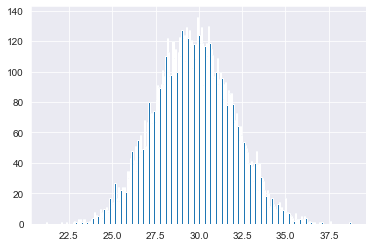

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('darkgrid') #Pretty background including grid lines for our backdrop
plt.hist(sample_means, bins=250);

Interesting! The first thing to note here is that the sample means form a normal distribution! What's more, let's take a look at the mean of our sample means:

In [ ]:
import numpy as np
np.mean(sample_means)

29.678139189972246

Wow! Look at that! The mean of our sample means is extremely close to the actual mean of the population! The mean of means of this simulation shows an accuracy of 99.9%

In [ ]:
population_mean = df.Age.mean()
mean_sample_means = np.mean(sample_means)
acc = 1 - (np.abs(mean_sample_means - population_mean) / population_mean)
print(acc)

0.9992936336582157


---

## The Central Limit Theorem

The central limit theorem states that, under many conditions, independent random variables summed together will converge to a normal distribution as the number of variables increases. This becomes very useful for applying statistical logic to sample statistics in order to estimate population parameters. For example, as we saw in the previous lecture, the averages of samples will form a normal distribution. We can then use this information to put further bounds on our estimates of the population. We can also use this information to estimate the probability of samples taking on extreme values that deviate from the population mean.  

For example, let's say that we know the mean and standard deviation of asthma rates in the United States. If we then take a sample from a specific city and find that the mean of this sample is substantially lower than that of the overall population, we may be interested in questions such as "what is the probability that this was just caused by random chance in sampling?" If the probability is exceedingly low, we have further reason to believe that this city has higher rates of asthma and that its population is statistically different then that of the general population.  

The computation would be something like this: we know the mean population, and by the central limit theorem, the average of various samples takes on a normal distribution. From that normal distribution of sample means, we can then compare the mean of our actual sample and compare it to the distribution of means. It should be quite rare that our sample mean falls outside 2 or 3 standard deviations from the mean of sample means, (roughly 2.35% and .15% respectively for each tail). As such, having a sample mean that falls outside of these scopes is worthy of further investigation.

For reference, here's is a rough empirical rule for percentiles within a normal distribution. (And again, by the central limit theorem, we expect our sample means to take on a normal distribution!)

<img src="assets/01_central_limit_theorem/new_CentralLimitTheorem.png" width="600">

---

## Practice: Applying the CLT

## Let's get started!

First, import the required libraries:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
np.random.seed(0) #set a random seed for reproducibility

Next, read in the dataset.  A dataset of 10,000 numbers is stored in `data/central_limit_theorem_lab/non_normal_dataset.csv`. Use pandas to read the data into a series.

**_Hint:_** Any of the `read_` methods in pandas will store 1-dimensional in a Series instead of a DataFrame if passed the optimal parameter `squeeze=True`.

In [ ]:
# Your code here

## Detecting Non-Normal Datasets

Before we can make use of the normal distribution, we need to first confirm that our data is normally distributed.  If it is not, then we'll need to use the Central Limit Theorem to create a sample distribution of sample means that will be normally distributed.  

There are two main ways to check if a sample follows the normal distribution or not.  The easiest is to simply plot the data and visually check if the data follows a normal curve or not.  

In the cell below, use `seaborn`'s `distplot` method to visualize a histogram of the distribution overlaid with the probability density curve.

In [ ]:
# Your code here

As expected, this dataset is not normally distributed.  

For a more formal way to check if a dataset is normally distributed or not, we can make use of a statistical test.  There are many different statistical tests that can be used to check for normality, but we'll keep it simple and just make use of the `normaltest()` function from `scipy.stats`, which we imported as `st` --see the [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.normaltest.html) if you have questions about how to use this method. 

In the cell below, use `normaltest()` to check if the dataset is normally distributed.

In [ ]:
# Your code here

The output may seem a bit hard to interpret since we haven't covered hypothesis testing and p-values in further detail yet.  However, the function tests the hypothesis that the distribution passed into the function differs from the normal distribution. The null hypothesis would then be that the data *is* normally distributed. We typically reject the null hypothesis if the p-value is less than 0.05. For now, that's all you need to remember--this will make more sense once you work with p-values more which you'll do subsequently.  

Since our dataset is non-normal, that means we'll need to use the **_Central Limit Theorem._**

## Sampling With Replacement

In order to create a Sample Distribution of Sample Means, we need to first write a function that can sample *with* replacement.  

In the cell below, write a function that takes in an array of numbers `data` and a sample size `n` and returns an array that is a random sample of `data`, of size `n`.

In [ ]:
def get_sample(data, n):
    pass

test_sample = get_sample(data, 30)
print(test_sample[:5]) 
# [56, 12, 73, 24, 8] (This will change if you run it multiple times)

## Generating a Sample Mean

Next, we'll write another helper function that takes in a sample and returns the mean of that sample.

In [ ]:
def get_sample_mean(sample):
    pass

test_sample2 = get_sample(data, 30)
test_sample2_mean = get_sample_mean(test_sample2)
print(test_sample2_mean) 
# 45.3 (This will also change if you run it multiple times)

### Creating a Sample Distribution of Sample Means

Now that we have helper functions to help us sample with replacement and calculate sample means, we just need to bring it all together and write a function that creates a sample distribution of sample means!

In the cell below, write a function that takes in 3 arguments: the dataset, the size of the distribution to create, and the size of each individual sample. The function should return a sample distribution of sample means of the given size.

In [ ]:
def create_sample_distribution(data, dist_size=100, n=30):
    pass

test_sample_dist = create_sample_distribution(data)
print(test_sample_dist[:5]) 

## Visualizing the Sample Distribution as it Becomes Normal

The sample distribution of sample means isn't guaranteed to be normal after it hits a magic size.  Instead, the distribution begins to approximate a normal distribution as it gets larger and larger.  Generally, 30 is accepted as the sample size where the Central Limit Theorem begins to kick in--however, there are no magic numbers when it comes to probability. On average, and only on average, a sample distribution of sample means where the individual sample sizes were 29 would only be slightly less normal, while one with sample sizes of 31 would likely only be slightly more normal.  

Let's create some sample distributions of different sizes and watch the Central Limit Theorem kick in. As the sample size increases, you'll see the distributions begin to approximate a normal distribution more closely.  

In the cell below, create a sample distribution from `data` of `dist_size` 10, with a sample size `n` of 3. Then, visualize this sample distribution with `distplot`.

In [ ]:
# Your code here

Now, let's increase the `dist_size` to 30, and `n` to 10.  Create another visualization to compare how it changes as size increases.

In [ ]:
# Your code here

The data is already looking much more 'normal' than the first sample distribution, and much more 'normal' that the raw non-normal distribution we're sampling from. 

In the cell below, create another sample distribution of `data` with `dist_size` 1000 and `n` of 30.  Visualize it to confirm the normality of this new distribution.

In [ ]:
# Your code here

Great! As you can see, the dataset _approximates_ a normal distribution. It isn't pretty, but it's generally normal enough that we can use it to answer statistical questions using $z$-scores and p-values.  

Another handy feature of the Central Limit Theorem is that the mean and standard deviation of the sample distribution should also approximate the population mean and standard deviation from the original non-normal dataset!  Although it's outside the scope of this lab, we could also use the same sampling methods seen here to approximate other parameters from any non-normal distribution, such as the median or mode!

---

## Practice: Sampling Statistics

## Background and Terminologies 

In order to learn the **population mean**, we don't measure the whole population. Instead, we take a random sample and use **sample mean, ( x_bar or $\bar{x}$ )** to estimate the population mean **( mu or $\mu$ )**. The sample mean is usually not exactly the same as the population mean and depends upon the values of samples chosen, however, the population mean remains fixed. While using the **sample mean** to estimate the population mean, we come across the **sampling error**, which directly relates to the **standard deviation** of a sampling statistic (e.g. mean values). This difference can be caused by many factors including poor survey design, biased sampling methods, and the randomness inherent to drawing a sample from a population.

Let's learn about these concepts through an example.

>**Pumpkin Weights**

>The population is the weight of six pumpkins (in pounds) displayed in a carnival "Guess the Weight" game booth. You are asked to guess the average weight of the six pumpkins by picking two pumpkins at a time randomly until all pumpkins have been used.

| Pumpkin | Weight (in pounds) |
|---------|--------------------|
| A       |       19           |
| B       |       14           |
| C       |       15           |
| D       |       9            |
| E       |       10           |
| F       |       17           |

## Step 1

Let's calculate the population mean first, which we calculate as:

**$\large \mu = \frac{\text{sum of all elements}}{N}$**, where N is population size.

In [ ]:
# Import necessary libraries
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import itertools

Create two lists, one with pumpkin names and one with the respective pumpkin weights. Combine the lists to create a pumpkin directory with the pumpkin names as keys and the pumpkin weights as values.

In [ ]:
# Create two lists with pumpkin names and weights

pumpkin = None
weights = None

# Combine both lists to create a dictionary

pumpkin_dict = None

print (pumpkin_dict)

#{'A': 19, 'B': 14, 'C': 15, 'D': 9, 'E': 10, 'F': 17}


Now, let's try to calculate the mean of the pumpkin population and also visualize the weight distribution.

In [ ]:
# Calculate the population mean from pumpkin_dict

def calculate_mu(x):

    # Use the formula for mu given above
    d = None   

    return (d)   

mu = calculate_mu(pumpkin_dict)
mu

# 14.0

That was a pretty a straightforward exercise. Let's use the data we have so far to visualize the weights of individual pumpkins and mean weight.

In [ ]:
# Plot a bar graph showing weights of pumpkins and highlight the mean weight



We can see only one pumpkin has a weight which is equal to the mean weight (B:14). Let's try to simulate the random sampling process as stated below.

## Step 2 : Calculate the mean of samples

From the `pumpkin_dict`, we can now obtain the sampling distributions of the sample mean for a given sample size. We'll do this while sampling *without* replacement (to reflect the idea that one can have two pumpkins at a given time, and will be taken out of population once used). 

Let's also try to make the code more flexible to allow sampling of any number of pumpkins from the population to study the effect of the sample size on the sample mean.

To achieve this, first, we need to identify all the possible combinations that can be observed by choosing 2 pumpkins from the population, following the game rule.

In [ ]:
# Identify a sample size n 
n = 2 

# Use itertools.combinations() to generate and print a list of combinations
combs = None


# Using 2 samples, we can see 15 possible combinations as below:
# [('A', 'B'), ('A', 'C'), ('A', 'D'), ('A', 'E'), ('A', 'F'), ('B', 'C'), ('B', 'D'), 
#  ('B', 'E'), ('B', 'F'), ('C', 'D'), ('C', 'E'), ('C', 'F'), ('D', 'E'), ('D', 'F'), 
#  ('E', 'F')]


Great! We can now generate any number of combinations from the population (try changing the value of `n` above). The next step in the process is to calculate the mean of all possible combinations and study whether these means differ from the population mean, and whether sample size has any effect on estimating the population mean. 

Let's write a function that would include the code for generating combinations as above and also for identifying the mean for each sample.

In [ ]:

def sample_means(sample_size, data):

    """
    This function takes in population data as a dictionary along with a chosen sample size 
    to generate all possible combinations of given sample size. 
    The function calculates the mean of each sample and returns:
    a) a list of all combinations ( as tuples ) 
    b) a list of means for all sample
    """

    n = sample_size

    # Calculate the mean of population
    mu = None
    #print ("Mean of population is:", mu)

    # Generate all possible combinations using given sample size
    combs = None

    # Calculate the mean weight (x_bar) for all the combinations (samples) using the given data
    x_bar_list = []

    # Calculate sample mean for all combinations and append to x_bar_list
 

    return combs, x_bar_list

n = 2 #Sample size

combs, means = sample_means(n, pumpkin_dict)

# Print the sample combinations with their means



# Using 2 samples, we can see 15 possible combinations as below:
# The mean of all sample means mu_x_hat is: 14.0
# ('A', 'B') 16.5
# ('A', 'C') 17.0
# ('A', 'D') 14.0
# ('A', 'E') 14.5
# ('A', 'F') 18.0
# ('B', 'C') 14.5
# ('B', 'D') 11.5
# ('B', 'E') 12.0
# ('B', 'F') 15.5
# ('C', 'D') 12.0
# ('C', 'E') 12.5
# ('C', 'F') 16.0
# ('D', 'E') 9.5
# ('D', 'F') 13.0
# ('E', 'F') 13.5
# The mean of all sample means mu_x_hat is: 14.0

Thus, even though each sample may give you an answer involving some error, the expected value is right at the target: exactly the population mean. In other words: 
>If one does the experiment over and over again, the overall average of the sample mean is exactly the population mean.

In the output above, we can see that some mean values i.e. 14.5, 12, are being repeated in the combinations. We can develop a frequency table to identify the probability of seeing a different mean value.

In [ ]:
def calculate_probability(means):
    '''
    Input: a list of means (x_hats)
    Output: a list of probablitity of each mean value
    '''
    #Calculate the frequency of each mean value
    freq = None

    prob = []

    # Calculate and append fequency of each mean value in the prob list. 

    return prob
    
probs = calculate_probability(means)

# Print combinations with sample means and probability of each mean value


# ('A', 'B') 16.5 1/15
# ('A', 'C') 17.0 1/15
# ('A', 'D') 14.0 1/15
# ('A', 'E') 14.5 2/15
# ('A', 'F') 18.0 1/15
# ('B', 'C') 14.5 2/15
# ('B', 'D') 11.5 1/15
# ('B', 'E') 12.0 2/15
# ('B', 'F') 15.5 1/15
# ('C', 'D') 12.0 2/15
# ('C', 'E') 12.5 1/15
# ('C', 'F') 16.0 1/15
# ('D', 'E') 9.5 1/15
# ('D', 'F') 13.0 1/15
# ('E', 'F') 13.5 1/15


Here, we see that the chance that the sample mean is exactly the population mean (i.e. 14) is only 1 in 15 (row 3), very small. It may also happen that the sample mean can never be the same value as the population mean. 

The difference between the sample mean and the population mean is known as the **Sampling Error**.  

>When using the sample mean to estimate the population mean, some possible error will be involved since random sample means are also random.

## Sample size and sampling error: 

Sample means cluster more closely around the population mean as the sample size increases. Thus, sampling error decreases as sample size increases.

Let's repeat the above exercise while increasing the sample size from 2 to 5.

In [ ]:
n = 5

# Use above functions to generate combinations as samples with means and calculate the probability of seeing
# each mean value  with sample size = 5.

# Using 5 samples with a population of size, we can see 6 possible combinations 
# The mean of all sample means mu_x_hat is: 14.0
# 1 ('A', 'B', 'C', 'D', 'E') 13.4 1/6
# 2 ('A', 'B', 'C', 'D', 'F') 14.8 1/6
# 3 ('A', 'B', 'C', 'E', 'F') 15.0 1/6
# 4 ('A', 'B', 'D', 'E', 'F') 13.8 1/6
# 5 ('A', 'C', 'D', 'E', 'F') 14.0 1/6
# 6 ('B', 'C', 'D', 'E', 'F') 13.0 1/6


Again, we see that using the sample mean to estimate the population mean involves sampling error. Sample means do not fully agree with the population mean. The mean of sample means, however, is still 14.

In order to fully appreciate the impact of sample size on estimating the population mean, let's try to visualize sample means and how the spread of values change when changing sample size. 

In a loop, run the above experiment with sample sizes ranging from 1 to 5 and measure and visualize the spread of values around the population mean.

In [ ]:
# Run a for loop to execute above code for sample size 1 to 5 and visualise the spread of sample 
# means



# Using 1 samples with a population of size, we can see 6 possible combinations 
# The mean of all sample means mu_x_hat is: 14.0

# Using 2 samples with a population of size, we can see 15 possible combinations 
# The mean of all sample means mu_x_hat is: 14.0

# Using 3 samples with a population of size, we can see 20 possible combinations 
# The mean of all sample means mu_x_hat is: 14.0

# Using 4 samples with a population of size, we can see 15 possible combinations 
# The mean of all sample means mu_x_hat is: 14.0

# Using 5 samples with a population of size, we can see 6 possible combinations 
# The mean of all sample means mu_x_hat is: 14.0

We can see that with increasing sample size, the **spread** of sample means is reduced and the sample mean values tend to come closer to the population mean.

## Step 3: Calculate the standard error

### So what is standard error?

The **_Standard Error (SE)_** is very similar to the standard deviation. Both are measures of spread. The higher the number, the more spread out your data is. To put it simply, the two terms are essentially equal — but there is one important difference. While the standard error uses statistics (sample data), standard deviations use parameters (population data). We achieve this by dividing the standard deviation by the square root of the sample size.

The calculation for the standard error of the sample mean is:

## $$ \sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}} \approx \frac{s}{\sqrt{n}}$$

Here, $\sigma$ is the population standard deviation (which we will approximate with the sample standard deviation $s$) and $n$ is the sample size.

Let's run the above block of code again and calculate the standard error according to the chosen sample size

In [ ]:
# Create empty lists for storing sample means, combinations and standard error for each iteration
means_list = []
combs_list = []
err_list = []
# Create a for loop with changing sample sizes
    
    # Calculate combinations, means as earlier, append to relevant lists

    

    # Calculate and append the standard error by dividing sample means with square root of sample size

    

    # Visualize sample spread and standard error values for each sample